In [111]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [112]:
def f(x):
    return 3*x**2 -4*x + 5

In [113]:
f(3.0)

20.0

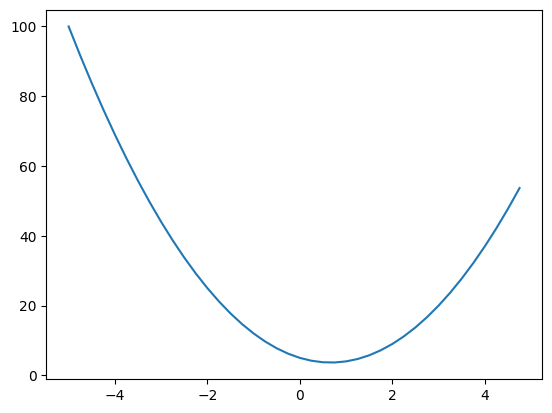

In [114]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

The derivative ... bump x by a small amount h and see how f(x) responds. What is the slope of a line between x and x+h?
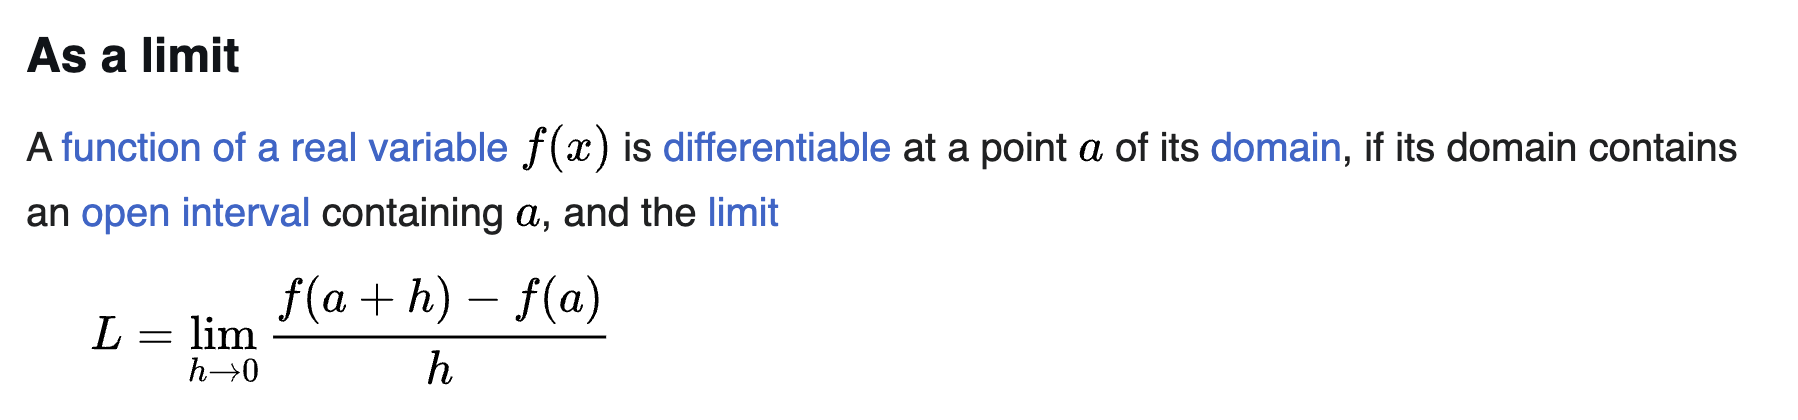

In [115]:
h = .0000001
x = 2/3
(f(x + h) - f(x))/h

2.9753977059954195e-07

In [116]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


now work on the derivative of d wrt a. Set h to a small number. calculate a first value for d. calculate a second value for d, bumped a little by h. So we can get the secant line between d1 and d2. If I were to shrink h, then the (d1 - d2)/h term would move to the slope of the tangent line (the derivative!) at a of d wrt a

In [117]:
h = 0.0001
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h
d2 = a*b + c
print('d1', d1)
print('d2', d2)

print('slope', (d2 - d1)/h)

d1 4.0
d2 3.999699999999999
slope -3.000000000010772


I understand the basic concept behind and how to get a derivative. Now we need to add some complexity to be able to use this concept with neural networks. Build the Value data structure.

Value will allow the creation of a network of expressions with each math operation being able to point "back" to its constituent pieces

In [118]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):#_children is an empty tuple. The underscore is a convention ... "internal"
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None #an inline function that returns nothing
        self._prev = set(_children) #the precursors for this value in the expression graph - the inputs to this operation
        self._op = _op #the operation to be performed
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other) #to be able to add just a number, wrap the number passed in into a Value object
        out = Value(self.data + other.data, (self, other), '+')#illustrates attaching the parameters as what comes before in the expression graph
        
        def _backward(): #this will be a closure as this function is defined in a scope where it has references to its parent's variables
            #out is the value housing the sum. out.grad is the influence that sum, the result of this addition has on the final node (L, in our example here)
            #self and other are inputs that result in out
            #self.grad is the influence that self has on the final node
            #other.grad is the influence that other has on the final node
            #if I know the influence out has on the final node and I know the influence dself has on dout then I know the influence dself has on the final node, or ....
            #dL/dself = dout/dself * dL/dout
            #dL/dout = out.grad
            #dout/dself = d(self + other)/dself = 1.0, becuause the derivative of 1 self + other (other is the constant) equals 1.0
            #So, self.grad = dL/dself = dout/dself * dL/dout = 1.0 * out.grad
            self.grad += 1.0 * out.grad #out.grad is the influence out has on the final node in the graph
            other.grad += 1.0 * out.grad #similarly ...

        out._backward = _backward
        return out
    
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other) #to be able to add just a number, wrap the number passed in into a Value object
        out = Value(self.data * other.data, (self, other), '*')

        def _backward(): #this will be a closure as this function is defined in a scope where it has references to its parent's variables
            self.grad += other.data * out.grad #out.grad is the influence out has on the final node in the graph
            #dL/dself = dL/dout * dout/dself = out.grad * other.data because the derivative of a '*' node is just the other operand per explanations below
            other.grad += self.data * out.grad

        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self * other
    
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh') #only one child, so (self, ) is Python for a tuple with only one element

        def _backward(): #this will be a closure as this function is defined in a scope where it has references to its parent's variables
            #dL/dself = dL/dout * dout/dself = dL/dout * dout/dx ~= dL/dout * dt/dx = dL/dout * (1 - t**2) = out.grad * (1 - t**2)
            self.grad += out.grad * (1 - t**2)
        
        out._backward = _backward
        return out
    
    def backward(self):
        topo = [] #builds a topological sort of the nodes, starting at the 'o' node but putting their .data values in left to right order
        visited = set()

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)

        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):# call backward() right to left on our topological sort
            node._backward()

In [119]:
a = Value(2.0)
a + 1
a * 14

2 * a

Value(data=4.0)

In [120]:
import os
import matplotlib.pyplot as plt
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='png', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  # Set a high DPI so the text remains completely sharp when plotted
  dot.attr(dpi='200')
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      dot.node(name = uid + n._op, label = n._op)
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  # 1. Save the graph temporarily as a PNG image on your disk
  filename = 'micrograd_temp_graph'
  dot.render(filename=filename, cleanup=True)
  
  # 2. Read the image back into Matplotlib and plot it
  img = plt.imread(filename + '.png')
  
  # Dynamically configure a wide figure box layout
  fig, ax = plt.subplots(figsize=(16, 4))
  ax.imshow(img)
  
  # Strip away the outer axis grids and numbers
  ax.axis('off')
  plt.tight_layout()
  
  # Clean up the local file from your directory
  if os.path.exists(filename + '.png'):
      os.remove(filename + '.png')
      
  return plt.show()


In [121]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2' #doing the dot product
n = x1w1x2w2 + b; n.label = 'n' # "sum" of errors
o = n.tanh(); o.label = 'o' #activation function applied

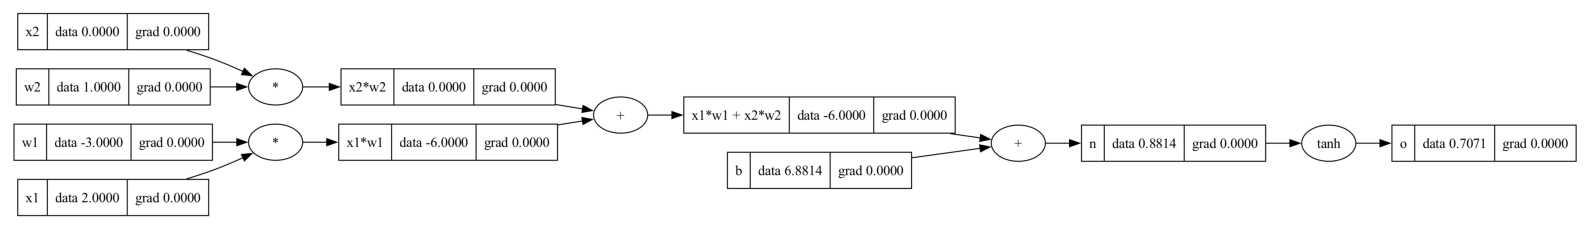

In [122]:
draw_dot(o)

In [123]:
o.backward() #THIS IS THE REAL/FINAL FUNCTION CALL TO USE

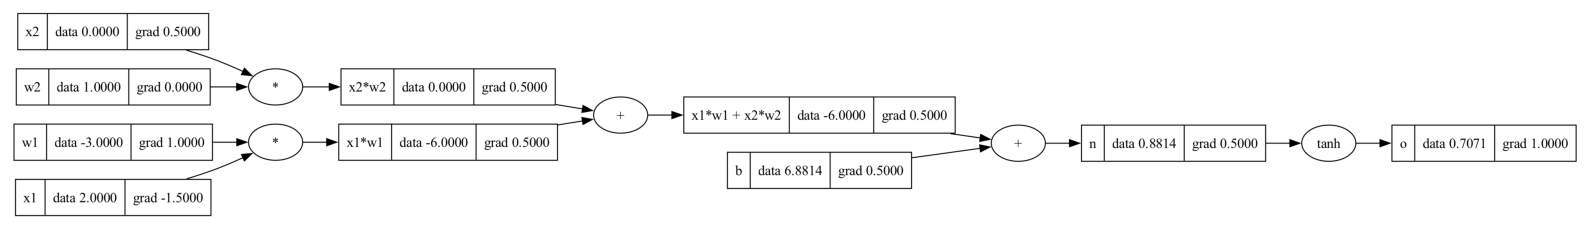

In [124]:
draw_dot(o) #THIS IS THE REAL/FINAL FUNCTION CALL TO USE